# Cs Gaussian Beam Omega-Stark Dictionary

This notebook computes the position-dependent Rabi-frequency reduction and differential AC Stark shift for a Cs atom in the waist plane of two Gaussian beams. The output JSON is designed to be used by pulse-shaping notebooks or Monte Carlo simulations.

The saved dictionary has the form

```json
{
  "0.0": {"omega_cs": 1.0, "cs_stark_shift": 0.0},
  "0.1": {"omega_cs": 0.99, "cs_stark_shift": -0.002}
}
```

The key is the atom displacement in units of the Gaussian beam sigma. The values are normalized by the maximum two-photon Rabi frequency at the beam center:

$$
\omega_{\mathrm{Cs}}(x)=\frac{|\Omega_R(x)|}{|\Omega_R(0)|},
$$

$$
\Delta_{\mathrm{Cs}}(x)=\frac{[\Delta_g(x)+\Delta_r(x)]-[\Delta_g(0)+\Delta_r(0)]}{|\Omega_R(0)|}.
$$

The center differential Stark shift is subtracted because the experimental detuning is assumed to be calibrated so that the beam center has zero effective detuning.

In [4]:
from __future__ import annotations

from dataclasses import dataclass
import json
import os
from pathlib import Path
import shutil
from typing import Protocol

notebook_dir = Path.cwd()
if not (notebook_dir / "pyproject.toml").exists():
    candidate_root = notebook_dir.parent.parent
    if (candidate_root / "pyproject.toml").exists():
        project_root = candidate_root
    else:
        project_root = notebook_dir
else:
    project_root = notebook_dir

os.environ.setdefault("MPLCONFIGDIR", str(notebook_dir / ".mpl-cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(notebook_dir / ".xdg-cache"))

import matplotlib.pyplot as plt
import numpy as np


## ARC Adapter

ARC's `twoPhotonRydbergExcitation` returns the two-photon Rabi frequency and AC Stark shifts for a given beam configuration. Here we use a local `Cesium133` subclass so ARC writes its cached atom data into the example folder instead of a global location.

The call follows ARC's argument order:

$$
\mathrm{twoPhotonRydbergExcitation}(P_p,w_p,q_p,P_c,w_c,q_c,\Delta,
 f_g,m_{f_g},n_e,l_e,j_e,n_r,l_r,j_r,m_{j_r}).
$$

Replace the powers, waists, detuning, polarizations, and state labels below with the values for the experiment being modeled.

In [5]:
@dataclass(frozen=True)
class TwoPhotonSettings:
    probe_power_w: float
    probe_waist_m: float
    probe_polarization: int
    coupling_power_w: float
    coupling_waist_m: float
    coupling_polarization: int
    ground_f: int
    ground_mf: int
    intermediate_n: int
    intermediate_l: int
    intermediate_j: float
    rydberg_n: int
    rydberg_l: int
    rydberg_j: float
    rydberg_mj: float


@dataclass(frozen=True)
class TwoPhotonResult:
    omega_r_rad_s: float
    delta_g_rad_s: float
    delta_r_rad_s: float
    scatter_probability: float


class TwoPhotonAtom(Protocol):
    def twoPhotonRydbergExcitation(
        self,
        probe_power_w: float,
        probe_waist_m: float,
        probe_polarization: int,
        coupling_power_w: float,
        coupling_waist_m: float,
        coupling_polarization: int,
        detuning_rad_s: float,
        ground_f: int,
        ground_mf: int,
        intermediate_n: int,
        intermediate_l: int,
        intermediate_j: float,
        rydberg_n: int,
        rydberg_l: int,
        rydberg_j: float,
        rydberg_mj: float,
    ) -> tuple[object, object, object, object]:
        raise NotImplementedError


def scalar_arc_value(value: object) -> float:
    array_value = np.asarray(value, dtype=np.float64)
    if array_value.size != 1:
        raise ValueError(f"Expected scalar ARC value, received shape {array_value.shape}.")
    return float(array_value.reshape(-1)[0])


def copy_arc_data(source: Path, destination: Path) -> None:
    if not source.exists():
        return
    destination.mkdir(parents=True, exist_ok=True)
    for item in source.iterdir():
        target = destination / item.name
        if item.is_file() and not target.exists():
            shutil.copy2(item, target)


def make_cesium133(arc_data_dir: Path) -> TwoPhotonAtom:
    try:
        import arc
        from arc import Cesium
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError("Install ARC with `pip install ARC-Alkali-Rydberg-Calculator`.") from exc

    package_data_dir = Path(arc.__file__).resolve().parent / "data"
    copy_arc_data(source=package_data_dir, destination=arc_data_dir)

    class LocalCesium133(Cesium):
        dataFolder = str(arc_data_dir)

    return LocalCesium133()


def run_two_photon(atom: TwoPhotonAtom, settings: TwoPhotonSettings, detuning_rad_s: float) -> TwoPhotonResult:
    omega_r, delta_g, delta_r, scatter = atom.twoPhotonRydbergExcitation(
        settings.probe_power_w,
        settings.probe_waist_m,
        settings.probe_polarization,
        settings.coupling_power_w,
        settings.coupling_waist_m,
        settings.coupling_polarization,
        detuning_rad_s,
        settings.ground_f,
        settings.ground_mf,
        settings.intermediate_n,
        settings.intermediate_l,
        settings.intermediate_j,
        settings.rydberg_n,
        settings.rydberg_l,
        settings.rydberg_j,
        settings.rydberg_mj,
    )
    return TwoPhotonResult(
        omega_r_rad_s=scalar_arc_value(omega_r),
        delta_g_rad_s=scalar_arc_value(delta_g),
        delta_r_rad_s=scalar_arc_value(delta_r),
        scatter_probability=scalar_arc_value(scatter),
    )


def total_stark_shift(result: TwoPhotonResult) -> float:
    return result.delta_g_rad_s + result.delta_r_rad_s


## Experiment Parameters

The parameter block below is an ARC-compatible Cs-133 example. It uses the Cs ground manifold, a 6P intermediate state, and an nS Rydberg state. The numbers are placeholders unless they match the lab setup.

The Gaussian convention used here is

$$
\frac{I(x)}{I(0)}=\exp\left[-\frac{1}{2}\left(\frac{x}{\sigma}\right)^2\right].
$$

Because the electric-field amplitude scales as the square root of intensity, scaling both beam powers by the same intensity factor gives the correct local single-photon Rabi-frequency reduction for a waist-plane displacement.

In [31]:
settings = TwoPhotonSettings(
    probe_power_w=70e-3,
    probe_waist_m=158e-6,
    probe_polarization=-1,
    coupling_power_w=10,
    coupling_waist_m=158e-6,
    coupling_polarization=1,
    ground_f=4,
    ground_mf=0,
    intermediate_n=7,
    intermediate_l=1,
    intermediate_j=1.5,
    rydberg_n=67,
    rydberg_l=0,
    rydberg_j=0.5,
    rydberg_mj=-0.5,
)

arc_data_dir = notebook_dir / ".arc-data"
output_path = notebook_dir / "cs_omega_stark_values.json"
sigma_positions = np.array([0.0, 0.05, 0.10, 0.15, 0.20], dtype=np.float64)

detuning_hz = 1.4e9
detuning_rad_s = 2.0 * np.pi * detuning_hz

atom = make_cesium133(arc_data_dir=arc_data_dir)


## Reference Stark Shift

We evaluate the center of the beam first. The center Rabi frequency defines the normalization scale, and the center differential Stark shift is the reference value that will be subtracted from all off-center values.

In [33]:
reference_result = run_two_photon(atom=atom, settings=settings, detuning_rad_s=detuning_rad_s)
reference_stark_shift_rad_s = total_stark_shift(result=reference_result)
omega_max_rad_s = abs(reference_result.omega_r_rad_s)

if omega_max_rad_s == 0.0:
    raise ValueError("The center two-photon Rabi frequency is zero; check the Cs ARC parameters.")

print(f"single_photon detuning = {detuning_hz / 1e9 :.6e} GHz")
print(f"Omega_max / 2pi = {omega_max_rad_s / (2.0 * np.pi) / 1e6 :.6e} MHz")
print(f"Reference Stark shift / 2pi = {reference_stark_shift_rad_s / (2.0 * np.pi) / 1e6 :.6e} MHz")
print(f"Scatter probability = {reference_result.scatter_probability:.6e}")


single_photon detuning = 1.400000e+00 GHz
Omega_max / 2pi = 2.090062e+00 MHz
Reference Stark shift / 2pi = 7.348716e+00 MHz
Scatter probability = 9.813834e-03


## Position Scan

For each displacement in units of sigma, both beam powers are multiplied by the Gaussian intensity factor. The saved Stark shift is the residual differential shift relative to the beam center.

In [34]:
def gaussian_intensity_scale(position_sigma: float) -> float:
    return float(np.exp(-0.5 * position_sigma**2))


def make_omega_stark_values(
    atom: TwoPhotonAtom,
    settings: TwoPhotonSettings,
    detuning_rad_s: float,
    positions_sigma: np.ndarray,
    omega_max_rad_s: float,
    reference_stark_shift_rad_s: float,
) -> dict[float, dict[str, float]]:
    values: dict[float, dict[str, float]] = {}
    for position_sigma_value in positions_sigma:
        position_sigma = float(position_sigma_value)
        intensity_scale = gaussian_intensity_scale(position_sigma=position_sigma)
        local_settings = TwoPhotonSettings(
            probe_power_w=settings.probe_power_w * intensity_scale,
            probe_waist_m=settings.probe_waist_m,
            probe_polarization=settings.probe_polarization,
            coupling_power_w=settings.coupling_power_w * intensity_scale,
            coupling_waist_m=settings.coupling_waist_m,
            coupling_polarization=settings.coupling_polarization,
            ground_f=settings.ground_f,
            ground_mf=settings.ground_mf,
            intermediate_n=settings.intermediate_n,
            intermediate_l=settings.intermediate_l,
            intermediate_j=settings.intermediate_j,
            rydberg_n=settings.rydberg_n,
            rydberg_l=settings.rydberg_l,
            rydberg_j=settings.rydberg_j,
            rydberg_mj=settings.rydberg_mj,
        )
        result = run_two_photon(atom=atom, settings=local_settings, detuning_rad_s=detuning_rad_s)
        values[position_sigma] = {
            "omega_cs": abs(result.omega_r_rad_s) / omega_max_rad_s,
            "cs_stark_shift": (total_stark_shift(result=result) - reference_stark_shift_rad_s) / omega_max_rad_s,
        }
    return values


def save_omega_stark_values(path: Path, values: dict[float, dict[str, float]]) -> None:
    serializable = {str(key): value for key, value in values.items()}
    path.write_text(json.dumps(serializable, indent=2, sort_keys=True), encoding="utf-8")


omega_stark_values = make_omega_stark_values(
    atom=atom,
    settings=settings,
    detuning_rad_s=detuning_rad_s,
    positions_sigma=sigma_positions,
    omega_max_rad_s=omega_max_rad_s,
    reference_stark_shift_rad_s=reference_stark_shift_rad_s,
)
save_omega_stark_values(path=output_path, values=omega_stark_values)
print(json.dumps({str(key): value for key, value in omega_stark_values.items()}, indent=2, sort_keys=True))
print(f"Saved {output_path}")


{
  "0.0": {
    "cs_stark_shift": 0.0,
    "omega_cs": 1.0
  },
  "0.05": {
    "cs_stark_shift": -0.0043922896504472835,
    "omega_cs": 0.9987507809245811
  },
  "0.1": {
    "cs_stark_shift": -0.017536264418650728,
    "omega_cs": 0.9950124791926824
  },
  "0.15": {
    "cs_stark_shift": -0.03933365199183068,
    "omega_cs": 0.9888130446112333
  },
  "0.2": {
    "cs_stark_shift": -0.06962202548074295,
    "omega_cs": 0.9801986733067553
  }
}
Saved /Users/lee/Documents/IQOQI/PulseShaping/time_optimal_grape/examples/stabilizer_readout/cs_omega_stark_values.json


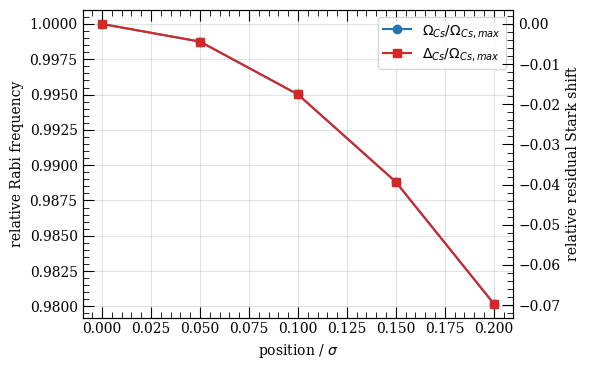

In [35]:
positions = np.array(sorted(omega_stark_values), dtype=np.float64)
omega_values = np.array([omega_stark_values[float(position)]["omega_cs"] for position in positions], dtype=np.float64)
stark_values = np.array([omega_stark_values[float(position)]["cs_stark_shift"] for position in positions], dtype=np.float64)

fig, ax_left = plt.subplots(figsize=(6.0, 3.8))
ax_right = ax_left.twinx()

ax_left.plot(positions, omega_values, marker="o", color="tab:blue", label=r"$\Omega_{Cs}/\Omega_{Cs,max}$")
ax_right.plot(positions, stark_values, marker="s", color="tab:red", label=r"$\Delta_{Cs}/\Omega_{Cs,max}$")

ax_left.set_xlabel(r"position / $\sigma$")
ax_left.set_ylabel(r"relative Rabi frequency")
ax_right.set_ylabel(r"relative residual Stark shift")
ax_left.grid(True, alpha=0.35)

left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_handles + right_handles, left_labels + right_labels, loc="best")
fig.tight_layout()
plt.show()


## Use In Other Notebooks

After running this notebook, load `cs_omega_stark_values.json` and pass the values into the Cs control or robustness scan. The dictionary stores dimensionless values, so the consuming code only needs the reference maximum Rabi frequency used for the pulse-time convention.